In [1]:
# Cell 1
# --- Imports ---
import os      # operating system tools: paths, directories
import re      # regular expressions for pattern matching (extract year from filename)
import glob    # file globbing: matches wildcards like "*.nc"

import xarray as xr   # to open NetCDF datasets
import numpy as np    # numerical array library (not yet used in this cell)


# ---- EDIT THIS: folder containing SMMR NetCDFs ----
# On your local machine this points to your repo.
# On the cluster, you'll want to change this path (or better: set via an environment variable).
DATA_DIR = "/Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/"

# File pattern to find all NetCDFs in that folder
GLOB_PAT = os.path.join(DATA_DIR, "*.nc")
# ----------------------------------------------
# Define the mission years you expect to find
# Here: 1979 through 2024 (Python range is end-exclusive, so 2025 means up to 2024)
YEARS = list(range(1979, 2025))


# Find all files matching the pattern (alphabetically sorted)
all_files = sorted(glob.glob(GLOB_PAT))


# --- Build a mapping from year -> file path ---
# Regex explanation:
#   r"(19|20)\d{2}"
#   - (19|20): matches either '19' or '20' (so years beginning with 19xx or 20xx)
#   - \d{2}: exactly two digits (so together, 1900–2099)
# Example: "advance_1985.nc" → match = "1985"
year_re = re.compile(r"(19|20)\d{2}")

year_to_path = {}
for f in all_files:
    # Extract just the filename, not the full path
    base = os.path.basename(f)

    # Search for the first 4-digit year pattern
    m = year_re.search(base)
    if not m:
        # If no year-like string is found, skip this file
        continue

    y = int(m.group(0))  # Convert the regex match (string) into an integer year

    # Only keep if the year is in our expected list and not already mapped
    if y in YEARS and y not in year_to_path:
        # Note: if multiple files exist for a given year, the first one wins.
        # Change this logic if you want the last one to override instead.
        year_to_path[y] = f


# --- Diagnostics ---
print("Discovered files for years:")
for y in YEARS:
    # Print either the path found or 'MISSING'
    print(f"  {y}: {year_to_path.get(y, 'MISSING')}")


# --- Peek inside the first available file ---
def list_phase_vars(nc_path):
    """
    Open a NetCDF file and return the list of variable names.
    Uses a context manager (`with`) so the file closes immediately after.
    """
    with xr.open_dataset(nc_path) as ds:
        return list(ds.data_vars)


# Find the first year in our range that we successfully mapped
first_path = next((year_to_path[y] for y in YEARS if y in year_to_path), None)

if first_path:
    print("\nExample variables in:", os.path.basename(first_path))
    print(list_phase_vars(first_path))
else:
    print("\nNo matching files found. Check DATA_DIR / pattern / YEARS.")

Discovered files for years:
  1979: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1979.nc
  1980: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1980.nc
  1981: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1981.nc
  1982: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1982.nc
  1983: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1983.nc
  1984: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1984.nc
  1985: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1985.nc
  1986: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1986.nc
  1987: /Users/fridaperez/Developer/repos/sea-ice-phase/results/SMMR_phase/seaice_phases_SMMR_1987.nc
  1988: /Users/fridaperez/Developer/repos/sea-ice-phas

In [2]:
# Cell 2 — Load advance/retreat across 1979–2023 into ('time','y','x')

YEARS = list(range(1979, 2024))  # inclusive 1979..2023

adv_list = []  # will hold per-year DataArrays for advance timing
ret_list = []  # will hold per-year DataArrays for retreat timing

for y in YEARS:
    path = year_to_path.get(y)   # from Cell 1: map year -> file path
    if path is None:
        print(f"Skipping {y} (no file found)")
        continue

    # Open once per year; context manager closes file promptly (good for cluster I/O)
    with xr.open_dataset(path) as ds:
        adv_var = f"advance_{y}"  # expected variable name pattern
        ret_var = f"retreat_{y}"

        # Defensive check: make sure both variables are present
        if adv_var not in ds or ret_var not in ds:
            print(f"Warning: {os.path.basename(path)} missing {adv_var} or {ret_var}")
            continue

        # Attach a 'time' coordinate equal to the integer year and ensure consistent (y,x) dims
        # expand_dims creates a new 'time' axis of length 1 with value [y]
        adv_list.append(ds[adv_var].expand_dims(time=[y]))
        ret_list.append(ds[ret_var].expand_dims(time=[y]))

# Concatenate all years along 'time' into a single DataArray each
adv_all = xr.concat(adv_list, dim="time")
ret_all = xr.concat(ret_list, dim="time")

print("Advance stacked:", adv_all.dims, adv_all.shape)
print("Retreat stacked:", ret_all.dims, ret_all.shape)
print("Years loaded:", adv_all.time.values)


Advance stacked: ('time', 'y', 'x') (45, 332, 316)
Retreat stacked: ('time', 'y', 'x') (45, 332, 316)
Years loaded: [1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992
 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006
 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020
 2021 2022 2023]


In [3]:
# Cell 3 — Build the 8-feature matrix (no plotting, no modeling)

import numpy as np
import xarray as xr

# --- Preconditions from Cell 2 ---
# adv_all: (time, y, x) DataArray with advance DOY for each year
# ret_all: (time, y, x) DataArray with retreat DOY for each year
assert 'adv_all' in globals() and 'ret_all' in globals(), "Run Cell 2 first."

# --- 0) Basic sanity (prevents silent misalignment) ---
assert adv_all.dims == ret_all.dims == ("time", "y", "x"), "Expect dims ('time','y','x')."
assert adv_all.sizes["y"] == ret_all.sizes["y"] and adv_all.sizes["x"] == ret_all.sizes["x"], "Grid mismatch."

# --- 1) Validity mask: require enough years on BOTH series (tune MIN_YEARS as needed) ---
MIN_YEARS = 25
n_adv = xr.apply_ufunc(np.isfinite, adv_all).sum("time")   # count of non-NaN per pixel
n_ret = xr.apply_ufunc(np.isfinite, ret_all).sum("time")
mask_grid = (n_adv >= MIN_YEARS) & (n_ret >= MIN_YEARS)    # (y, x) boolean

# --- 2) Purist leap-year handling for all angle/duration computations ---
def _is_leap_year(years_da):
    y = years_da.astype(int)
    return ((y % 4 == 0) & ((y % 100 != 0) | (y % 400 == 0)))

year_len = xr.where(_is_leap_year(adv_all["time"]), 366.0, 365.0)   # (time,)

# --- 3) Circular means for advance/retreat (encode timing correctly on the circle) ---
TAU = 2.0 * np.pi
theta_adv = TAU * ((adv_all % year_len) / year_len)     # (time, y, x) angles in radians
theta_ret = TAU * ((ret_all % year_len) / year_len)

# mean unit-vector components (dimensionless, wrap-safe)
cbar_adv = np.cos(theta_adv).mean("time", skipna=True)   # (y, x)
sbar_adv = np.sin(theta_adv).mean("time", skipna=True)
cbar_ret = np.cos(theta_ret).mean("time", skipna=True)
sbar_ret = np.sin(theta_ret).mean("time", skipna=True)

# resultant lengths (concentration ∈ [0,1]): how stable the timing is across years
R_adv = np.hypot(cbar_adv, sbar_adv)                    # (y, x)
R_ret = np.hypot(cbar_ret, sbar_ret)

# --- 4) Season duration (days) per year, then interannual mean & std ---
# Definition used here: "ice-season length" = (retreat - advance) wrapped by that year's length
duration = (ret_all - adv_all) % year_len               # (time, y, x) in days
dur_mean_days = duration.mean("time", skipna=True)       # (y, x)
dur_std_days  = duration.std("time",  skipna=True)       # (y, x)

# Optional sanity screen (do NOT delete silently; keep it explicit if you choose to apply)
# plausible = (dur_mean_days >= 20) & (dur_mean_days <= 360)
# mask_grid = mask_grid & plausible

# --- 5) Assemble features and flatten to (N, 8) using the mask ---
feat_names = [
    "adv_cos", "adv_sin",
    "ret_cos", "ret_sin",
    "R_adv", "R_ret",
    "dur_mean_days", "dur_std_days",
]

# Stack into ('feat','y','x') for clean reshape → then flatten valid pixels only
feat_da = xr.concat(
    [cbar_adv, sbar_adv, cbar_ret, sbar_ret, R_adv, R_ret, dur_mean_days, dur_std_days],
    dim=xr.IndexVariable("feat", feat_names)
)  # dims: ('feat','y','x')

F, Y, X = feat_da.sizes["feat"], feat_da.sizes["y"], feat_da.sizes["x"]
vals = feat_da.values.reshape(F, Y * X).T          # (Y*X, 8)
mask_vec = mask_grid.values.reshape(Y * X)         # (Y*X,)
X8_raw = vals[mask_vec]                            # (N, 8) — unstandardized features

# --- 6) Leave everything in well-named variables for later cells ---
# For interpretation/plots later:
#   cbar_adv, sbar_adv, cbar_ret, sbar_ret, R_adv, R_ret, dur_mean_days, dur_std_days
# For modeling in Cell 4:
#   X8_raw (N,8), feat_names, mask_grid, grid shape
grid_shape = (Y, X)

print("Built features:")
print("  X8_raw shape (N,8):", X8_raw.shape)
print("  Valid pixel fraction:", float(mask_grid.mean().values))
print("  Feature order:", feat_names)


Built features:
  X8_raw shape (N,8): (28361, 8)
  Valid pixel fraction: 0.2703313253012048
  Feature order: ['adv_cos', 'adv_sin', 'ret_cos', 'ret_sin', 'R_adv', 'R_ret', 'dur_mean_days', 'dur_std_days']


/Users/fridaperez/miniconda3/envs/seaice/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[GMM] K=10, best seed=13, BIC=-119813 (mean±sd across seeds: -114881 ± 2548)
Converged: True
labels_grid: (332, 316) | uncert_grid: (332, 316) | uncert (min/med/max): 0.0 4.185194585337726e-07 0.5615135055436835


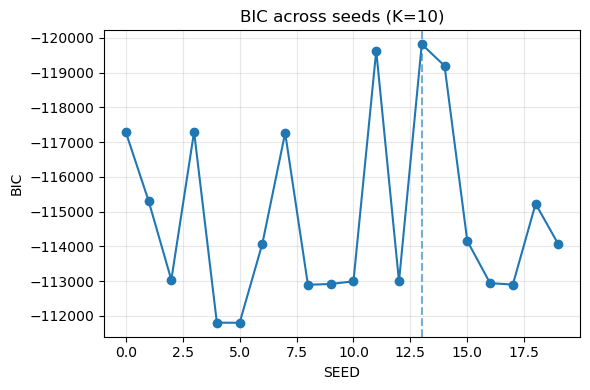

/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_28082/1213736406.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_disc = plt.cm.get_cmap('tab20', K_found) if K_found <= 20 else plt.cm.get_cmap('nipy_spectral', K_found)


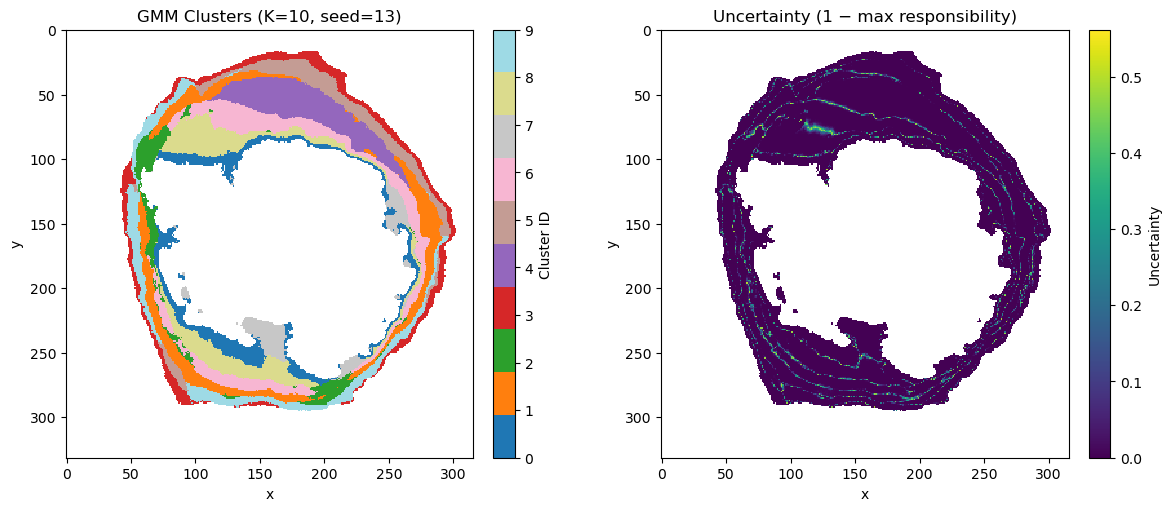

In [4]:
# ==== CELL 4 ====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Preconditions (made in Cell 3)
assert 'X8_raw' in globals() and 'mask_grid' in globals() and 'grid_shape' in globals(), \
    "Run Cells 1–3 first to create X8_raw, mask_grid, grid_shape."

# --- 0) Standardize features (explicit; avoids silent sklearn StandardScaler state) ---
mu   = np.nanmean(X8_raw, axis=0)
sig  = np.nanstd(X8_raw, axis=0, ddof=0)
sig  = np.where(sig == 0.0, 1.0, sig)  # guard
X8_z = (X8_raw - mu) / sig

# --- 1) Fit GMM for fixed K across multiple seeds; keep best by BIC ---
K = 10
seeds = list(range(20))    # bump if you want more restarts
gmms, bics = [], []

for s in seeds:
    gm = GaussianMixture(
        n_components=K,
        covariance_type='full',
        random_state=s,
        n_init=1,
        max_iter=500,
        reg_covar=1e-6
    ).fit(X8_z)
    gmms.append(gm)
    bics.append(gm.bic(X8_z))

bics = np.array(bics)
best_idx  = int(np.argmin(bics))
best_seed = seeds[best_idx]
gmm_best  = gmms[best_idx]

print(f"[GMM] K={K}, best seed={best_seed}, BIC={bics[best_idx]:.0f} "
      f"(mean±sd across seeds: {bics.mean():.0f} ± {bics.std():.0f})")
print("Converged:", bool(gmm_best.converged_))

# --- 2) Responsibilities → hard labels & uncertainty (1 - max resp) ---
probs       = gmm_best.predict_proba(X8_z)     # (N, K)
labels_1d   = probs.argmax(axis=1)             # (N,)
uncert_1d   = 1.0 - probs.max(axis=1)          # (N,)

# --- 3) Map 1D vectors back to (y, x) grids using existing mask ---
def to_grid(vec_1d, mask_bool, shape, fill=np.nan):
    yx = np.full(shape, fill, dtype=float).ravel()
    m  = np.asarray(mask_bool, dtype=bool).ravel()
    yx[m] = vec_1d.astype(float)
    return yx.reshape(shape)

labels_grid = to_grid(labels_1d, mask_grid, grid_shape, fill=np.nan)
uncert_grid = to_grid(uncert_1d, mask_grid, grid_shape, fill=np.nan)

print("labels_grid:", labels_grid.shape, "| uncert_grid:", uncert_grid.shape,
      "| uncert (min/med/max):",
      float(np.nanmin(uncert_grid)), float(np.nanmedian(uncert_grid)), float(np.nanmax(uncert_grid)))

# --- 4) Quick BIC vs seed plot (lower is better) ---
plt.figure(figsize=(6,4))
plt.plot(seeds, bics, marker='o')
plt.axvline(best_seed, ls='--', alpha=0.6)
plt.xlabel('SEED')
plt.ylabel('BIC')
plt.title(f'BIC across seeds (K={K})')
plt.grid(alpha=0.3)
plt.gca().invert_yaxis()  # optional visual convention
plt.tight_layout()
plt.show()

# --- 5) Simple spatial plots: clusters (discrete) + uncertainty (continuous) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

# Panel A: cluster IDs
K_found = int(np.nanmax(labels_grid)) + 1
cmap_disc = plt.cm.get_cmap('tab20', K_found) if K_found <= 20 else plt.cm.get_cmap('nipy_spectral', K_found)

im1 = ax1.imshow(labels_grid, origin='upper', interpolation='nearest', cmap=cmap_disc)
ax1.set_title(f'GMM Clusters (K={K}, seed={best_seed})')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
cb1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label('Cluster ID')

# Panel B: uncertainty
im2 = ax2.imshow(uncert_grid, origin='upper', interpolation='nearest', cmap='viridis')
ax2.set_title('Uncertainty (1 − max responsibility)')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
cb2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label('Uncertainty')

plt.show()

# --- 6) Keep results handy for later cells / saving ---
gmm_results = {
    'K': K,
    'best_seed': best_seed,
    'bics': bics,
    'labels_1d': labels_1d,
    'uncert_1d': uncert_1d,
    'labels_grid': labels_grid,
    'uncert_grid': uncert_grid,
    'feat_mean': mu,
    'feat_std': sig,
    'model': gmm_best,
}



In [5]:
# Save quick artifacts you’ll reuse later
np.savez_compressed(
    'gmm_k10_outputs.npz',
    K=gmm_results['K'],
    best_seed=gmm_results['best_seed'],
    bics=gmm_results['bics'],
    labels_1d=gmm_results['labels_1d'],
    uncert_1d=gmm_results['uncert_1d'],
    labels_grid=gmm_results['labels_grid'],
    uncert_grid=gmm_results['uncert_grid'],
    feat_mean=gmm_results['feat_mean'],
    feat_std=gmm_results['feat_std']
)
print("Saved: gmm_k10_outputs.npz")


Saved: gmm_k10_outputs.npz


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# Preconditions from your Cell 3
assert 'X8_raw' in globals() and 'feat_names' in globals() 
assert 'mask_grid' in globals() and 'grid_shape' in globals()

# Standardize once (explicit)
mu  = np.nanmean(X8_raw, axis=0)
sd  = np.nanstd(X8_raw, axis=0, ddof=0)
sd  = np.where(sd == 0.0, 1.0, sd)
X8_z = (X8_raw - mu) / sd

def to_grid(vec_1d, mask_bool, shape, fill=np.nan):
    out = np.full(shape, fill, dtype=float).ravel()
    m   = np.asarray(mask_bool, dtype=bool).ravel()
    out[m] = np.asarray(vec_1d, dtype=float)
    return out.reshape(shape)

def fit_gmm_across_seeds(X, K, seeds, covariance_type='full', max_iter=500, reg_covar=1e-6):
    """Fit GMM at fixed K across seeds; return dict with models, BICs, probs, labels."""
    models, bics, probs_list, labels_list = [], [], [], []
    for s in seeds:
        gm = GaussianMixture(n_components=K, covariance_type=covariance_type,
                             random_state=s, n_init=1, max_iter=max_iter, reg_covar=reg_covar).fit(X)
        models.append(gm)
        bics.append(gm.bic(X))
        P = gm.predict_proba(X)
        probs_list.append(P)
        labels_list.append(P.argmax(axis=1))
    bics = np.asarray(bics)
    best_idx = int(np.argmin(bics))
    return {
        'models': models, 'bics': bics, 'probs': probs_list, 'labels': labels_list,
        'best_idx': best_idx, 'best_seed': seeds[best_idx], 'best_model': models[best_idx]
    }

def plot_bic_vs_seed(bics, seeds, K):
    plt.figure(figsize=(6,4))
    plt.plot(seeds, bics, marker='o')
    plt.axvline(seeds[int(np.argmin(bics))], ls='--', alpha=.6)
    plt.xlabel('SEED'); plt.ylabel('BIC'); plt.title(f'BIC across seeds (K={K})')
    plt.grid(alpha=.3); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

def ari_stability(labels_list):
    """Returns ARI vs reference (first run) and full pairwise ARI matrix."""
    S = len(labels_list)
    ari_vs_ref = [adjusted_rand_score(labels_list[0], labels_list[s]) for s in range(S)]
    ari_mat = np.zeros((S, S))
    for i in range(S):
        for j in range(S):
            ari_mat[i, j] = adjusted_rand_score(labels_list[i], labels_list[j])
    return np.array(ari_vs_ref), ari_mat

def plot_ari_stability(ari_vs_ref, ari_mat, seeds, K, ylim=(0,1)):
    fig = plt.figure(figsize=(12,4.5))
    ax1 = fig.add_subplot(1,2,1)
    ax1.plot(seeds, ari_vs_ref, marker='o')
    ax1.set_title(f'Stability at K={K} (ARI vs ref)')
    ax1.set_xlabel('seed'); ax1.set_ylabel('Adjusted Rand Index'); ax1.set_ylim(*ylim)
    ax1.grid(alpha=.3)

    ax2 = fig.add_subplot(1,2,2)
    im = ax2.imshow(ari_mat, vmin=0, vmax=1, origin='upper')
    ax2.set_title('Pairwise ARI across seeds')
    ax2.set_xlabel('seed'); ax2.set_ylabel('seed')
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()


K=10: best seed=11, BIC=-119627, mean±sd BIC=-114694 ± 2482


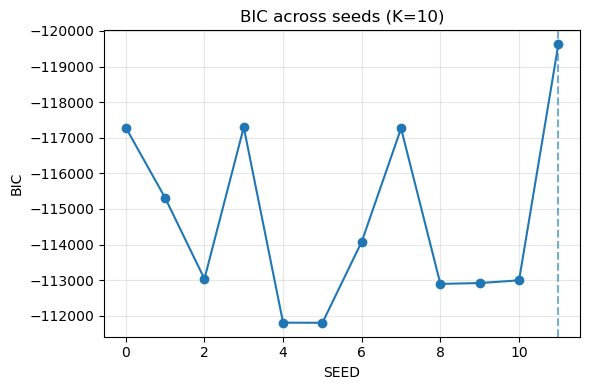

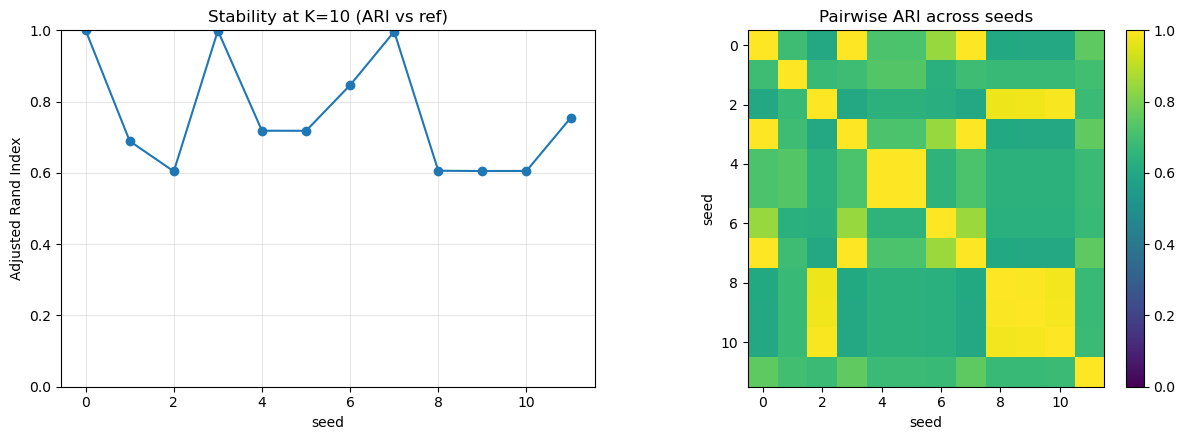

K=12: best seed=9, BIC=-154609, mean±sd BIC=-149524 ± 2260


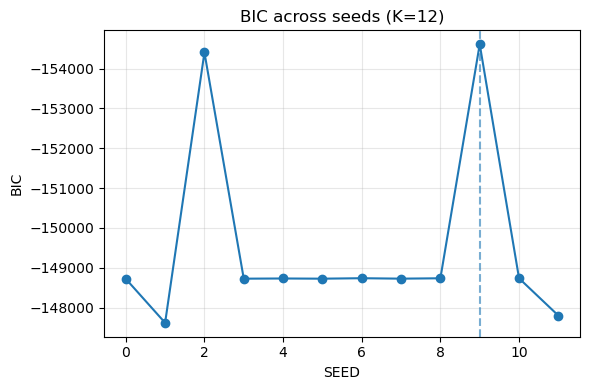

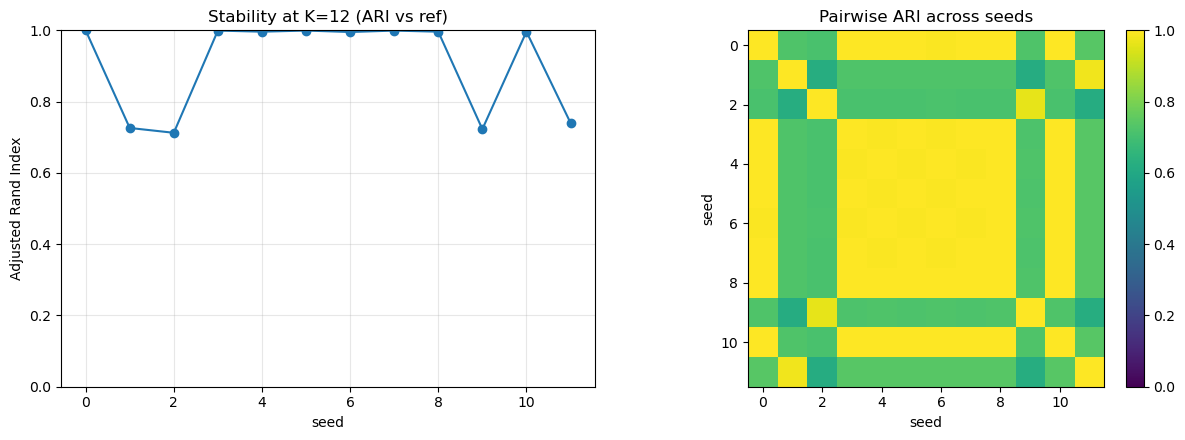

K=10: ARI vs ref median=0.718, IQR=(0.606, 0.884)
K=12: ARI vs ref median=0.996, IQR=(0.737, 0.999)


In [8]:
seeds = list(range(12))  # 12 restarts is usually enough to see stability patterns

results_by_K = {}
for K in (10, 12):
    res = fit_gmm_across_seeds(X8_z, K=K, seeds=seeds)
    results_by_K[K] = res
    print(f"K={K}: best seed={res['best_seed']}, BIC={res['bics'][res['best_idx']]:.0f}, "
          f"mean±sd BIC={res['bics'].mean():.0f} ± {res['bics'].std():.0f}")
    plot_bic_vs_seed(res['bics'], seeds, K)
    ari_vs_ref, ari_mat = ari_stability(res['labels'])
    plot_ari_stability(ari_vs_ref, ari_mat, seeds, K)

# Quick “decision” print:
for K, res in results_by_K.items():
    ari_vs_ref, _ = ari_stability(res['labels'])
    print(f"K={K}: ARI vs ref median={np.median(ari_vs_ref):.3f}, IQR=({np.percentile(ari_vs_ref,25):.3f}, {np.percentile(ari_vs_ref,75):.3f})")


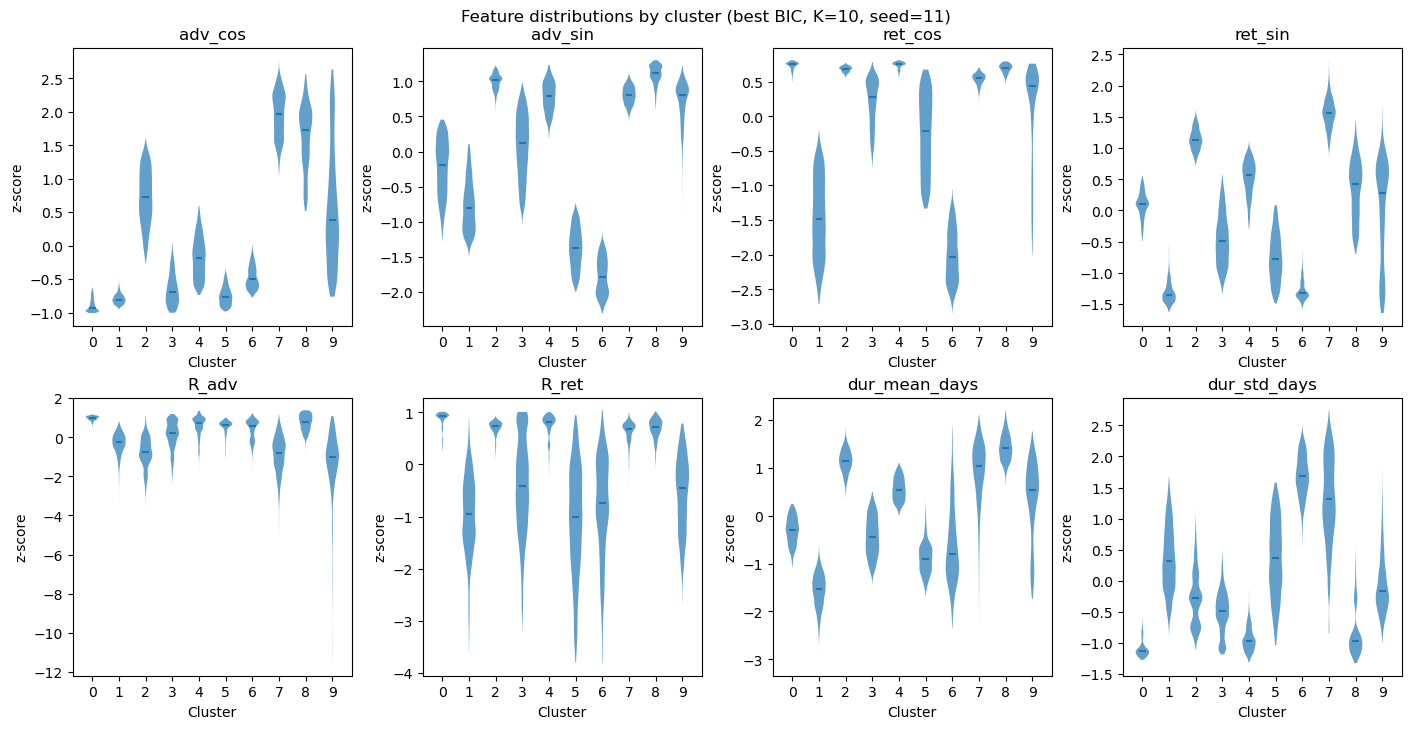

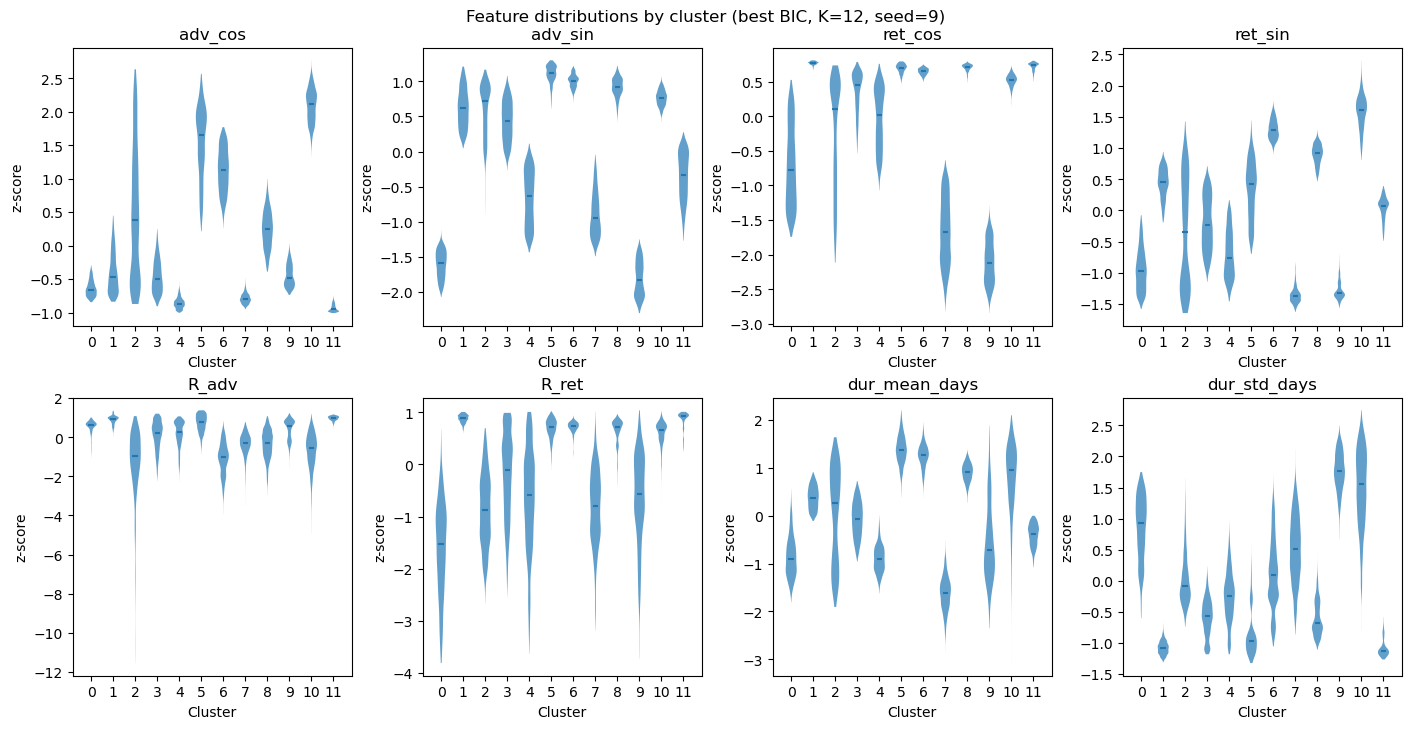

In [9]:
def plot_feature_violins(X, labels, feat_names, K, seed):
    K_found = labels.max() + 1
    assert K_found == K, f"Expected {K} clusters, got {K_found}"
    fig, axes = plt.subplots(2, 4, figsize=(14,7), constrained_layout=True)
    axes = axes.ravel()
    
    for i, ax in enumerate(axes[:len(feat_names)]):
        data = [X[labels==k, i] for k in range(K)]
        parts = ax.violinplot(data, showmedians=True, showextrema=False)
        ax.set_title(feat_names[i])
        ax.set_xlabel('Cluster'); ax.set_ylabel('z-score')
        ax.set_xticks(range(1, K+1)); ax.set_xticklabels(range(K))
        for pc in parts['bodies']: pc.set_alpha(0.7)

    fig.suptitle(f'Feature distributions by cluster (best BIC, K={K}, seed={seed})', y=1.02)
    plt.show()

# Plot for K=10
res10 = results_by_K[10]
labels10 = res10['labels'][res10['best_idx']]
plot_feature_violins(X8_z, labels10, feat_names, K=10, seed=res10['best_seed'])

# Plot for K=12 (only if you still care to inspect)
res12 = results_by_K[12]
labels12 = res12['labels'][res12['best_idx']]
plot_feature_violins(X8_z, labels12, feat_names, K=12, seed=res12['best_seed'])


K=6: best seed=2, best BIC=-16979
K=8: best seed=1, best BIC=-72610
K=10: best seed=3, best BIC=-117296
K=12: best seed=9, best BIC=-154609


/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_28082/1610285795.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_disc = plt.cm.get_cmap('tab20', int(np.nanmax(lab_grid))+1)


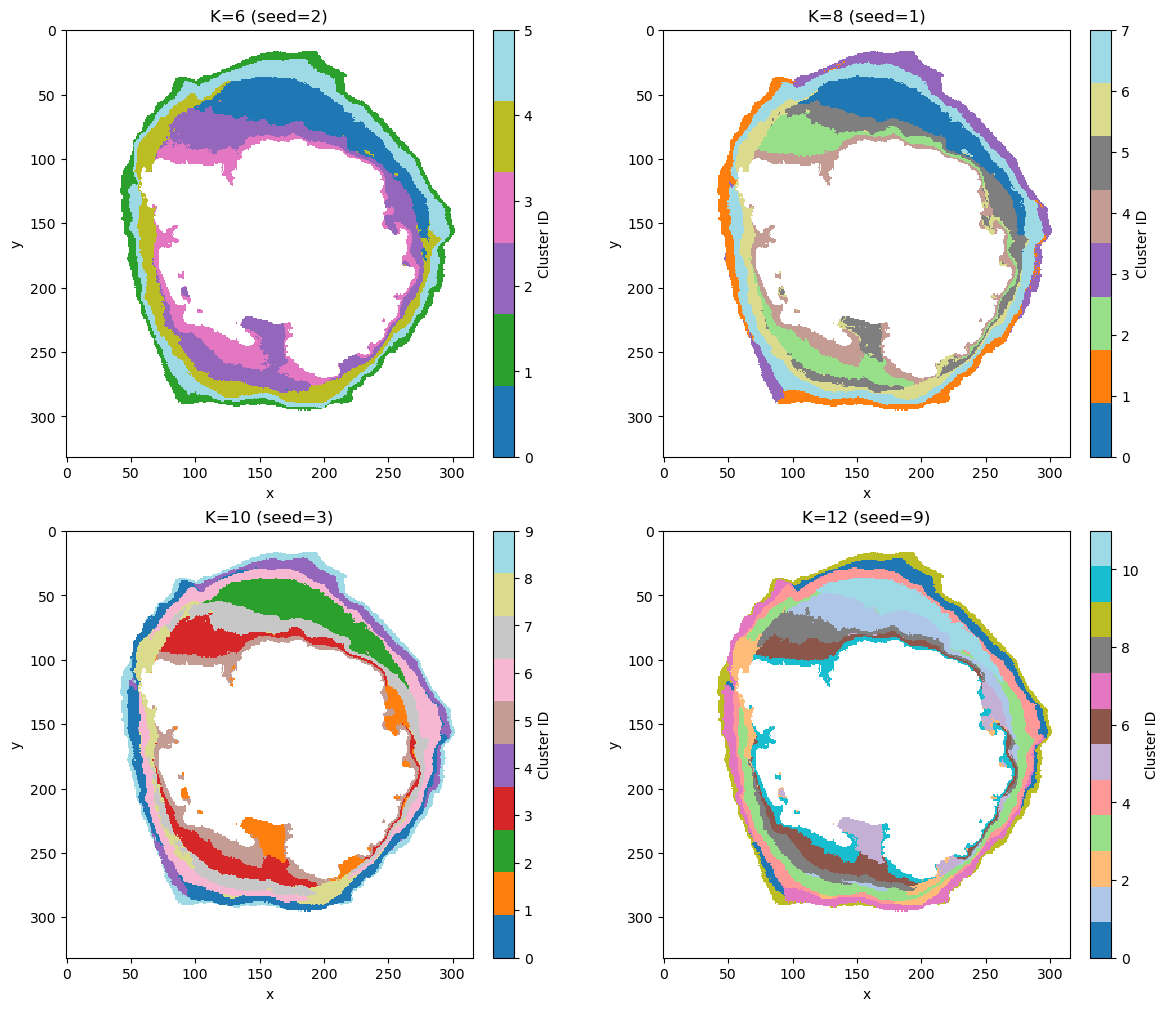

In [10]:
Ks_compare = (6, 8, 10, 12)
labels_grids = {}
best_seeds = {}

for K in Ks_compare:
    res = fit_gmm_across_seeds(X8_z, K=K, seeds=list(range(10)))
    best = res['best_idx']
    labels_1d = res['labels'][best]
    labels_grids[K] = to_grid(labels_1d, mask_grid, grid_shape)
    best_seeds[K] = res['best_seed']
    print(f"K={K}: best seed={res['best_seed']}, best BIC={res['bics'][best]:.0f}")

# Plot 2x2 panel
fig, axes = plt.subplots(2, 2, figsize=(12,10), constrained_layout=True)
for ax, K in zip(axes.ravel(), Ks_compare):
    lab_grid = labels_grids[K]
    cmap_disc = plt.cm.get_cmap('tab20', int(np.nanmax(lab_grid))+1)
    im = ax.imshow(lab_grid, origin='upper', interpolation='nearest', cmap=cmap_disc)
    ax.set_title(f"K={K} (seed={best_seeds[K]})")
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Cluster ID')
plt.show()


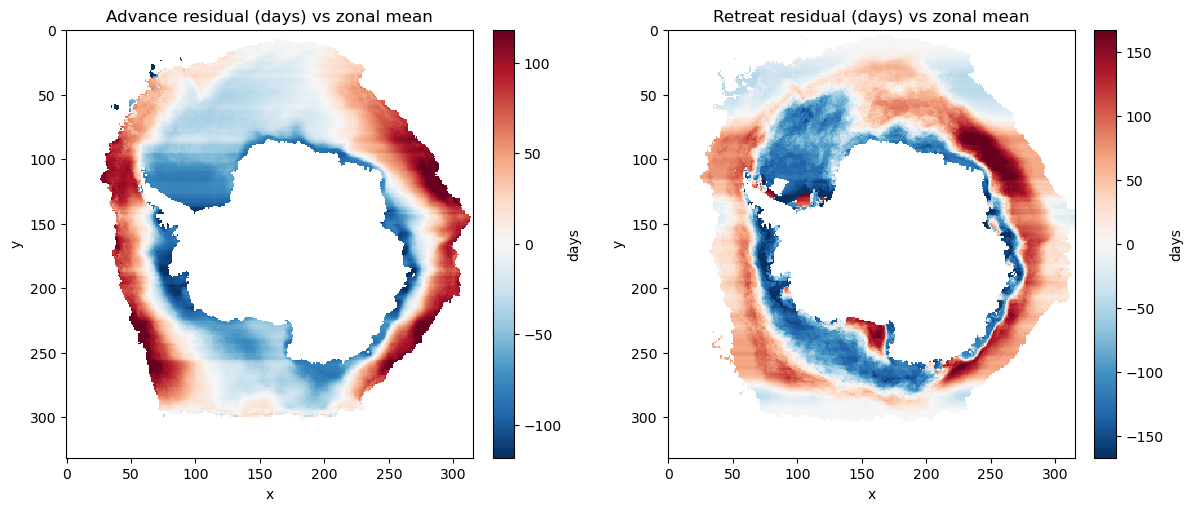

In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Preconditions: adv_all, ret_all from Cell 2; dims ('time','y','x')
assert adv_all.dims == ('time','y','x') and ret_all.dims == ('time','y','x')

# 1) Climatological means (time-average, in days)
adv_clim = adv_all.mean('time', skipna=True)   # (y,x)
ret_clim = ret_all.mean('time', skipna=True)   # (y,x)

# 2) Zonal means (mean across longitude x) for each latitude row y
adv_zonal_y = adv_clim.mean('x', skipna=True)  # (y,)
ret_zonal_y = ret_clim.mean('x', skipna=True)  # (y,)

# 3) Broadcast zonal means back to (y,x) and compute residuals (days)
adv_zonal_2d = adv_zonal_y.broadcast_like(adv_clim)
ret_zonal_2d = ret_zonal_y.broadcast_like(ret_clim)

adv_res_days = (adv_clim - adv_zonal_2d)       # positive = later than zonal mean; negative = earlier
ret_res_days = (ret_clim - ret_zonal_2d)

# 4) Quick maps (imshow on native grid)
def _imshow_res(ax, da, title, cmap='RdBu_r'):
    v = float(np.nanmax(np.abs(da.values)))
    v = np.percentile(np.abs(da.values[np.isfinite(da.values)]), 98) if np.isfinite(da.values).any() else 1.0
    im = ax.imshow(da, origin='upper', cmap=cmap, vmin=-v, vmax=+v, interpolation='nearest')
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
    return im

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
im1 = _imshow_res(ax1, adv_res_days, 'Advance residual (days) vs zonal mean')
im2 = _imshow_res(ax2, ret_res_days, 'Retreat residual (days) vs zonal mean')
for ax, im in [(ax1, im1), (ax2, im2)]:
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('days')
plt.show()


/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_28082/1135797143.py:17: RuntimeWarning: Mean of empty slice
  c = np.nanmean(np.cos(theta_2d), axis=1)  # (y,)
/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_28082/1135797143.py:18: RuntimeWarning: Mean of empty slice
  s = np.nanmean(np.sin(theta_2d), axis=1)  # (y,)


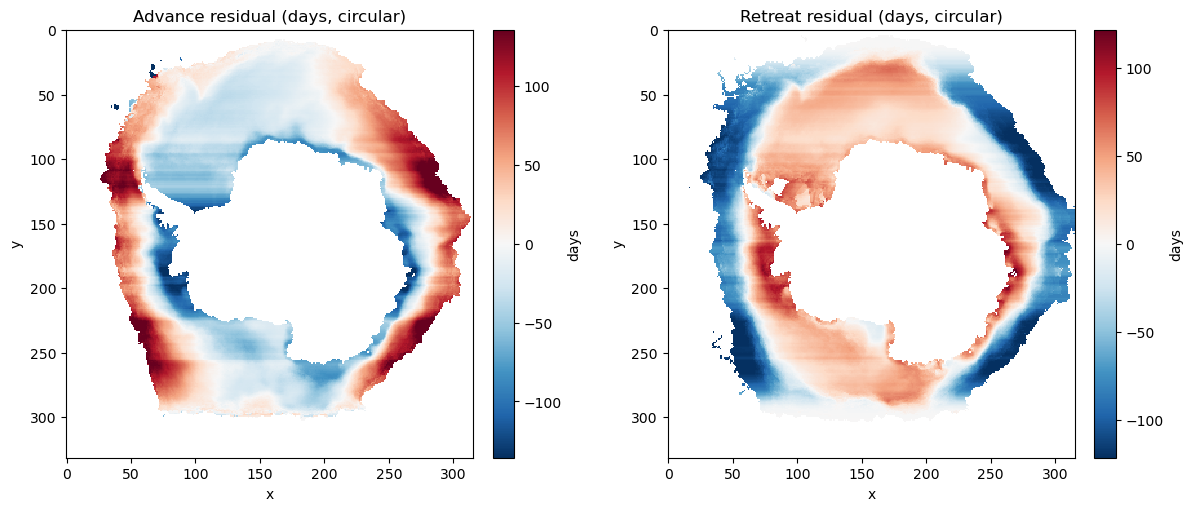

In [13]:
import numpy as np
import matplotlib.pyplot as plt

TAU = 2*np.pi
DAYS = 365.2425  # climatological year length

# Preconditions from Cell 3: cbar_adv, sbar_adv, cbar_ret, sbar_ret (each (y,x))
assert all(name in globals() for name in ['cbar_adv','sbar_adv','cbar_ret','sbar_ret'])

# 1) Local mean phase angles (advance/retreat) in radians
theta_adv = np.arctan2(sbar_adv.values, cbar_adv.values)  # (y,x)
theta_ret = np.arctan2(sbar_ret.values, cbar_ret.values)  # (y,x)

# 2) Zonal mean phases via vector average along x (avoid angle wrap bugs)
def zonal_phase_mean(theta_2d):
    # compute mean cos,sin across x, then angle
    c = np.nanmean(np.cos(theta_2d), axis=1)  # (y,)
    s = np.nanmean(np.sin(theta_2d), axis=1)  # (y,)
    return np.arctan2(s, c)                   # (y,)

theta_adv_zonal_y = zonal_phase_mean(theta_adv)
theta_ret_zonal_y = zonal_phase_mean(theta_ret)

# 3) Broadcast to (y,x)
theta_adv_zonal_2d = np.broadcast_to(theta_adv_zonal_y[:,None], theta_adv.shape)
theta_ret_zonal_2d = np.broadcast_to(theta_ret_zonal_y[:,None], theta_ret.shape)

# 4) Circular residuals Δθ in [-π, π]
def circ_diff(a, b):
    d = a - b
    return (d + np.pi) % (2*np.pi) - np.pi

adv_res_phase = circ_diff(theta_adv, theta_adv_zonal_2d)  # radians
ret_res_phase = circ_diff(theta_ret, theta_ret_zonal_2d)  # radians

# 5) Convert to days (using constant year length; adequate for climatology)
adv_res_days_circ = (adv_res_phase / TAU) * DAYS
ret_res_days_circ = (ret_res_phase / TAU) * DAYS

# 6) Plot
def _show(ax, A, title):
    vmax = np.nanpercentile(np.abs(A[np.isfinite(A)]), 98) if np.isfinite(A).any() else 1.0
    im = ax.imshow(A, origin='upper', cmap='RdBu_r', vmin=-vmax, vmax=+vmax, interpolation='nearest')
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y')
    return im

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)
im1 = _show(ax1, adv_res_days_circ, 'Advance residual (days, circular)')
im2 = _show(ax2, ret_res_days_circ, 'Retreat residual (days, circular)')
for ax, im in [(ax1, im1), (ax2, im2)]:
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label('days')
plt.show()


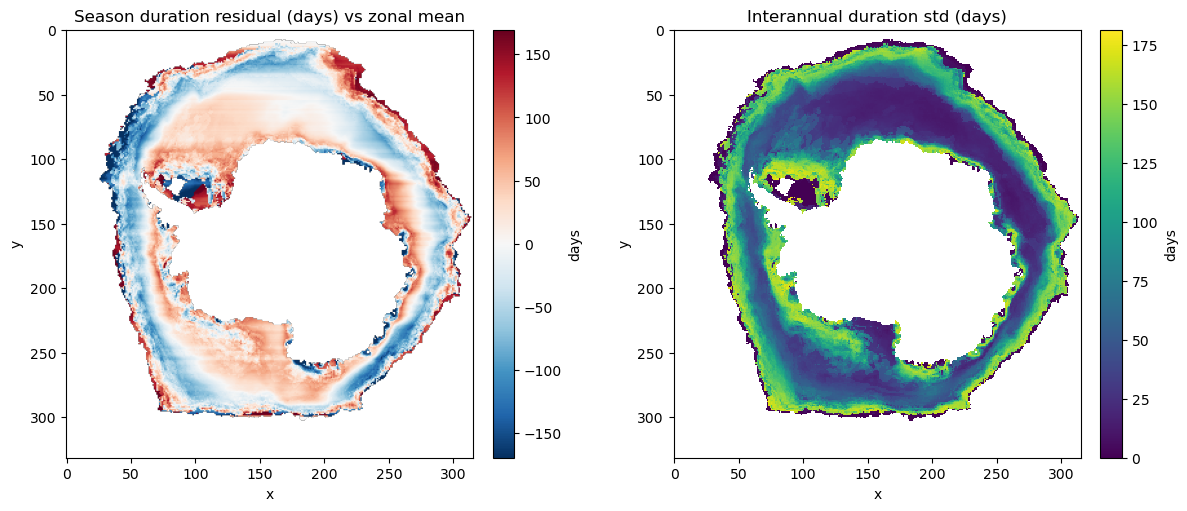

In [14]:
# Preconditions: dur_mean_days, dur_std_days from Cell 3
assert 'dur_mean_days' in globals() and 'dur_std_days' in globals()

# Zonal mean of duration, residual in days
dur_zonal_y = dur_mean_days.mean('x', skipna=True)           # (y,)
dur_zonal_2d = dur_zonal_y.broadcast_like(dur_mean_days)     # (y,x)
dur_res_days = (dur_mean_days - dur_zonal_2d).values         # (y,x)

# Plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5), constrained_layout=True)
im1 = ax1.imshow(dur_res_days, origin='upper', cmap='RdBu_r',
                 vmin=-np.nanpercentile(np.abs(dur_res_days),98),
                 vmax=+np.nanpercentile(np.abs(dur_res_days),98))
ax1.set_title('Season duration residual (days) vs zonal mean'); ax1.set_xlabel('x'); ax1.set_ylabel('y')
cb1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04); cb1.set_label('days')

im2 = ax2.imshow(dur_std_days, origin='upper', cmap='viridis', interpolation='nearest')
ax2.set_title('Interannual duration std (days)'); ax2.set_xlabel('x'); ax2.set_ylabel('y')
cb2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04); cb2.set_label('days')
plt.show()


In [15]:
# Build detrended features on a common mask (your existing mask_grid)
Y, X = grid_shape
mask_flat = mask_grid.values.reshape(Y*X)

# Flatten grids to (N,) using mask
def flat_from_grid(A):
    return np.asarray(A).reshape(Y*X)[mask_flat]

# Use circular phase residuals (days), duration residual (days), plus variability (R_adv, R_ret, dur_std_days)
feat_list = [
    flat_from_grid(adv_res_days_circ),
    flat_from_grid(ret_res_days_circ),
    flat_from_grid(dur_res_days),
    flat_from_grid(R_adv.values),
    flat_from_grid(R_ret.values),
    flat_from_grid(dur_std_days.values),
]
X_res_raw = np.vstack(feat_list).T  # (N, 6)
feat_names_res = ['adv_res_days', 'ret_res_days', 'dur_res_days', 'R_adv', 'R_ret', 'dur_std']

# Standardize
mu_res = np.nanmean(X_res_raw, axis=0)
sd_res = np.nanstd(X_res_raw, axis=0, ddof=0)
sd_res = np.where(sd_res==0, 1.0, sd_res)
X_res_z = (X_res_raw - mu_res) / sd_res

print("Detrended feature matrix:", X_res_z.shape, feat_names_res)


Detrended feature matrix: (28361, 6) ['adv_res_days', 'ret_res_days', 'dur_res_days', 'R_adv', 'R_ret', 'dur_std']


## Fitting new features with detrenden longitude

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

assert 'X_res_z' in globals() and 'mask_grid' in globals() and 'grid_shape' in globals()
assert 'feat_names_res' in globals()

def to_grid(vec_1d, mask_bool, shape, fill=np.nan):
    out = np.full(shape, fill, dtype=float).ravel()
    m   = np.asarray(mask_bool, dtype=bool).ravel()
    out[m] = np.asarray(vec_1d, dtype=float)
    return out.reshape(shape)

def fit_gmm_across_seeds(X, K, seeds, covariance_type='full', max_iter=500, reg_covar=1e-6):
    models, bics, probs_list, labels_list = [], [], [], []
    for s in seeds:
        gm = GaussianMixture(
            n_components=K, covariance_type=covariance_type,
            random_state=s, n_init=1, max_iter=max_iter, reg_covar=reg_covar
        ).fit(X)
        models.append(gm)
        bics.append(gm.bic(X))
        P = gm.predict_proba(X)
        probs_list.append(P)
        labels_list.append(P.argmax(axis=1))
    bics = np.asarray(bics)
    best_idx = int(np.argmin(bics))
    return {
        'models': models, 'bics': bics, 'probs': probs_list, 'labels': labels_list,
        'best_idx': best_idx, 'best_seed': seeds[best_idx], 'best_model': models[best_idx]
    }

def ari_stability(labels_list):
    S = len(labels_list)
    ari_vs_ref = [adjusted_rand_score(labels_list[0], labels_list[s]) for s in range(S)]
    ari_mat = np.zeros((S, S))
    for i in range(S):
        for j in range(S):
            ari_mat[i, j] = adjusted_rand_score(labels_list[i], labels_list[j])
    return np.array(ari_vs_ref), ari_mat

def plot_bic_vs_seed(bics, seeds, K):
    plt.figure(figsize=(6,4))
    plt.plot(seeds, bics, marker='o')
    plt.axvline(seeds[int(np.argmin(bics))], ls='--', alpha=.6)
    plt.xlabel('SEED'); plt.ylabel('BIC'); plt.title(f'BIC across seeds (K={K})')
    plt.grid(alpha=.3); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

def plot_ari_stability(ari_vs_ref, ari_mat, seeds, K, ylim=(0,1)):
    fig = plt.figure(figsize=(12,4.5))
    ax1 = fig.add_subplot(1,2,1)
    ax1.plot(seeds, ari_vs_ref, marker='o')
    ax1.set_title(f'Stability at K={K} (ARI vs ref)')
    ax1.set_xlabel('seed'); ax1.set_ylabel('Adjusted Rand Index'); ax1.set_ylim(*ylim)
    ax1.grid(alpha=.3)
    ax2 = fig.add_subplot(1,2,2)
    im = ax2.imshow(ari_mat, vmin=0, vmax=1, origin='upper')
    ax2.set_title('Pairwise ARI across seeds')
    ax2.set_xlabel('seed'); ax2.set_ylabel('seed')
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

def plot_feature_violins(X, labels, feat_names, K, seed, title_prefix='Detrended'):
    K_found = labels.max() + 1
    assert K_found == K, f"Expected {K} clusters, got {K_found}"
    rows = 2
    cols = int(np.ceil(len(feat_names)/rows))
    fig, axes = plt.subplots(rows, cols, figsize=(1.8+3.0*cols, 1.8+3.0*rows), constrained_layout=True)
    axes = axes.ravel()
    for i, ax in enumerate(axes[:len(feat_names)]):
        data = [X[labels==k, i] for k in range(K)]
        parts = ax.violinplot(data, showmedians=True, showextrema=False)
        ax.set_title(feat_names[i])
        ax.set_xlabel('Cluster'); ax.set_ylabel('z-score')
        ax.set_xticks(range(1, K+1)); ax.set_xticklabels(range(K))
        for pc in parts['bodies']: pc.set_alpha(0.7)
    for ax in axes[len(feat_names):]:
        ax.axis('off')
    fig.suptitle(f'{title_prefix} feature distributions by cluster (K={K}, seed={seed})', y=1.02)
    plt.show()


[Detrended] K=6: best seed=0, best BIC=245056, mean±sd BIC=248340 ± 2887


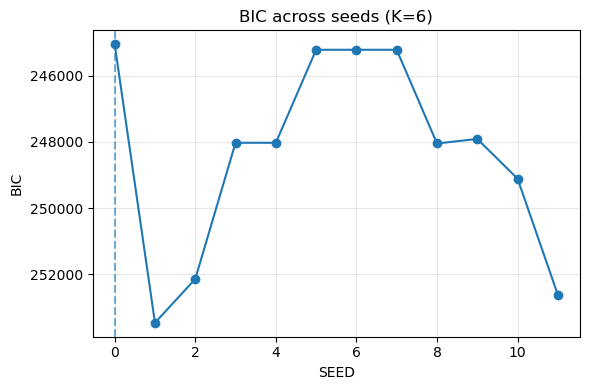

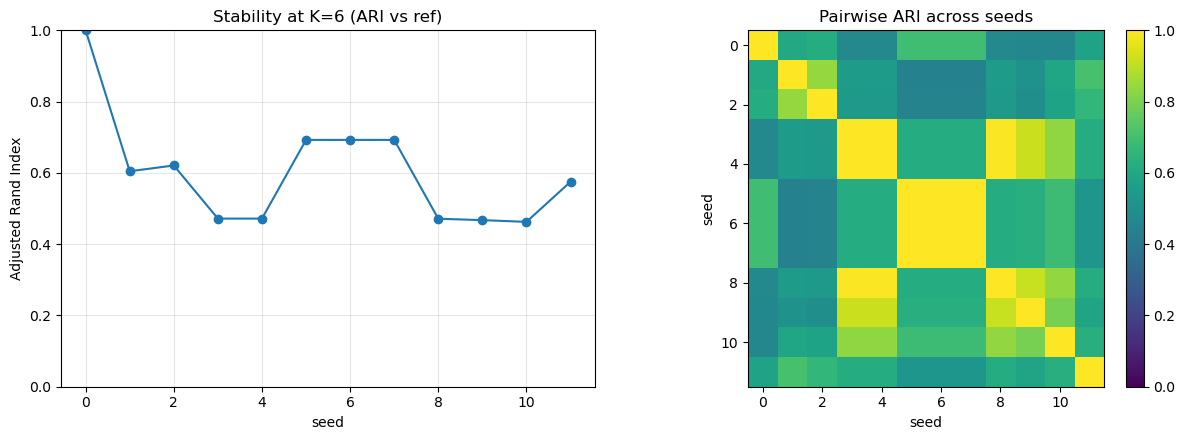

[Detrended] K=8: best seed=2, best BIC=226030, mean±sd BIC=229222 ± 3512


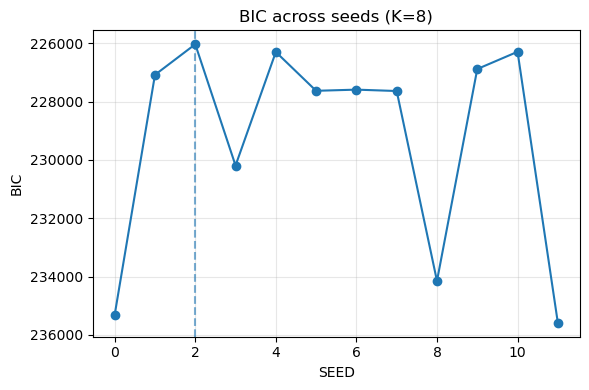

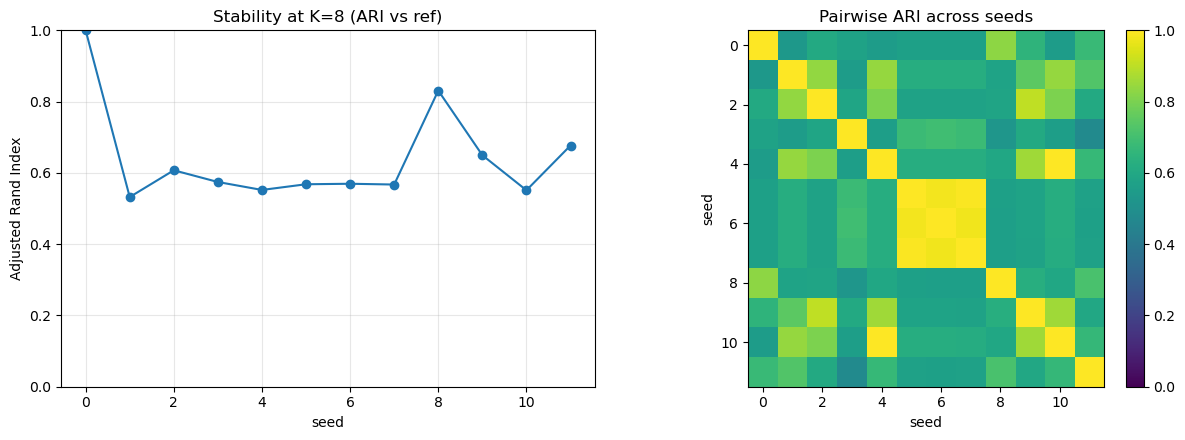

[Detrended] K=10: best seed=6, best BIC=211334, mean±sd BIC=215389 ± 3135


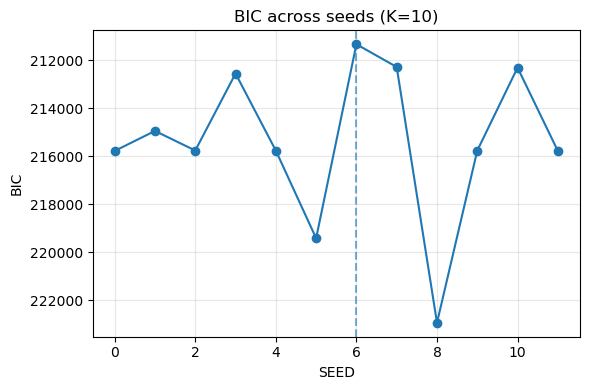

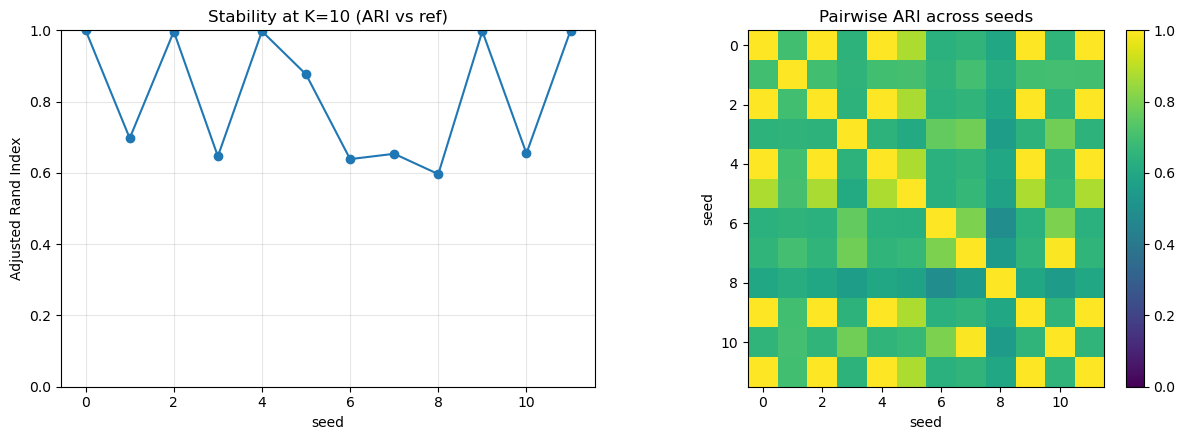

[Detrended] K=12: best seed=10, best BIC=200915, mean±sd BIC=205958 ± 2645


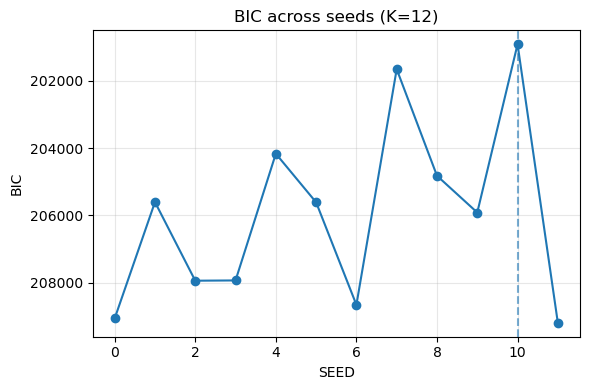

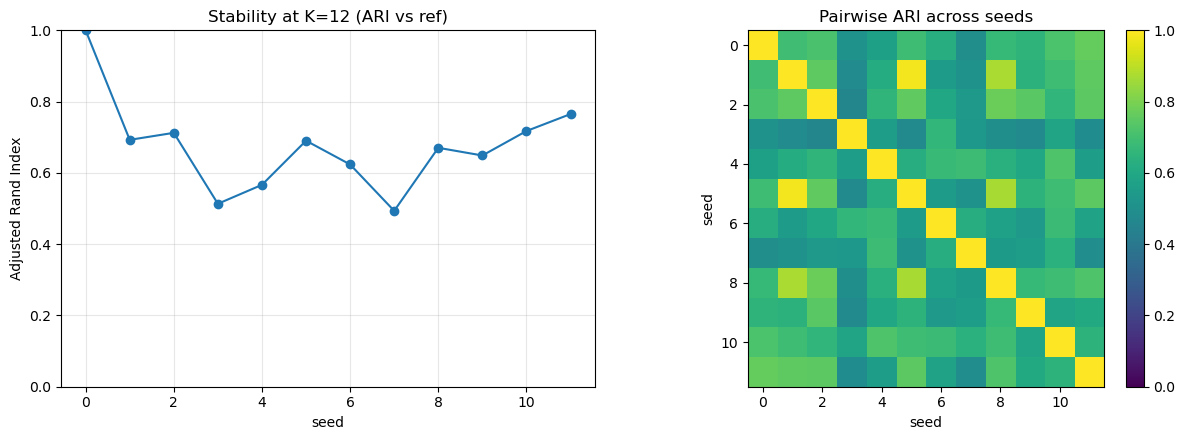

[Detrended] K=6: ARI median=0.590, IQR=(0.472,0.693)
[Detrended] K=8: ARI median=0.572, IQR=(0.564,0.656)
[Detrended] K=10: ARI median=0.787, IQR=(0.652,0.998)
[Detrended] K=12: ARI median=0.680, IQR=(0.609,0.714)


In [18]:
Ks = [6, 8, 10, 12]       # adjust as you like
seeds = list(range(12))

res_det = {}
for K in Ks:
    r = fit_gmm_across_seeds(X_res_z, K=K, seeds=seeds)
    res_det[K] = r
    print(f"[Detrended] K={K}: best seed={r['best_seed']}, best BIC={r['bics'][r['best_idx']]:.0f}, "
          f"mean±sd BIC={r['bics'].mean():.0f} ± {r['bics'].std():.0f}")
    plot_bic_vs_seed(r['bics'], seeds, K)
    ari_vs_ref, ari_mat = ari_stability(r['labels'])
    plot_ari_stability(ari_vs_ref, ari_mat, seeds, K)

# Quick summary line
for K, r in res_det.items():
    ari_vs_ref, _ = ari_stability(r['labels'])
    print(f"[Detrended] K={K}: ARI median={np.median(ari_vs_ref):.3f}, IQR=({np.percentile(ari_vs_ref,25):.3f},{np.percentile(ari_vs_ref,75):.3f})")


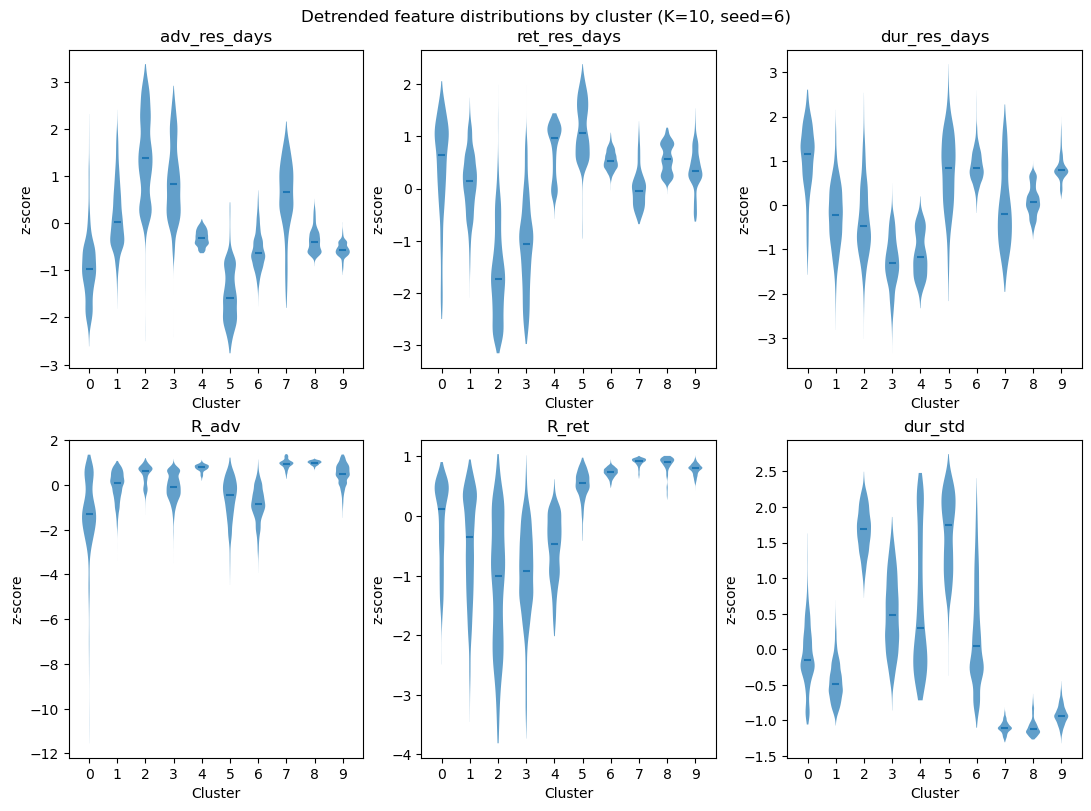

In [19]:
Kstar = 10  # or choose after you see D2/D3
r = res_det[Kstar]
labels_star = r['labels'][r['best_idx']]
plot_feature_violins(X_res_z, labels_star, feat_names_res, K=Kstar, seed=r['best_seed'],
                     title_prefix='Detrended')


[Detrended] K=10  | best seed=6, best BIC=211334
[Detrended] K=12  | best seed=10, best BIC=200915


/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_28082/2781180808.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap10 = plt.cm.get_cmap('tab20', int(np.nanmax(lab10))+1)
/var/folders/f1/8zx2wbhx4vb8626x_99mwyx40000gn/T/ipykernel_28082/2781180808.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap12 = plt.cm.get_cmap('tab20', int(np.nanmax(lab12))+1)


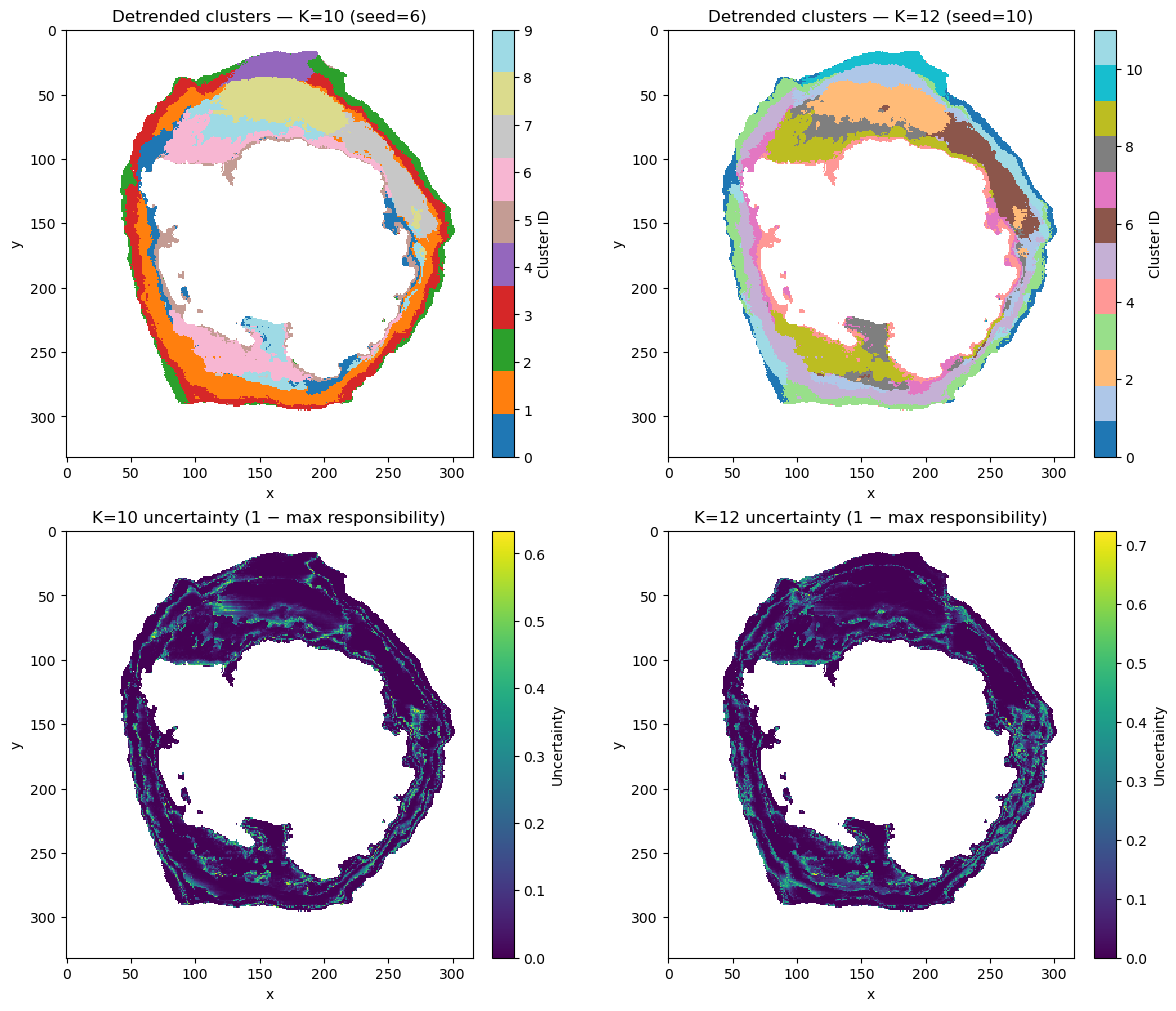

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def best_of(res):
    b = res['best_idx']
    return {
        'seed': res['best_seed'],
        'bic': float(res['bics'][b]),
        'labels_1d': res['labels'][b],
        'probs': res['probs'][b]
    }

res10 = best_of(res_det[10])
res12 = best_of(res_det[12])

# Map labels back to (y,x)
lab10 = to_grid(res10['labels_1d'], mask_grid, grid_shape)
lab12 = to_grid(res12['labels_1d'], mask_grid, grid_shape)

# OPTIONAL: simple uncertainty (1 - max responsibility) maps
unc10 = to_grid(1.0 - res10['probs'].max(axis=1), mask_grid, grid_shape)
unc12 = to_grid(1.0 - res12['probs'].max(axis=1), mask_grid, grid_shape)

print(f"[Detrended] K=10  | best seed={res10['seed']}, best BIC={res10['bic']:.0f}")
print(f"[Detrended] K=12  | best seed={res12['seed']}, best BIC={res12['bic']:.0f}")

# --- Side-by-side maps: labels + uncertainty
fig, axes = plt.subplots(2, 2, figsize=(12,10), constrained_layout=True)

# K=10 labels
cmap10 = plt.cm.get_cmap('tab20', int(np.nanmax(lab10))+1)
im = axes[0,0].imshow(lab10, origin='upper', cmap=cmap10, interpolation='nearest')
axes[0,0].set_title(f"Detrended clusters — K=10 (seed={res10['seed']})")
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')
plt.colorbar(im, ax=axes[0,0], fraction=0.046, pad=0.04, label='Cluster ID')

# K=12 labels
cmap12 = plt.cm.get_cmap('tab20', int(np.nanmax(lab12))+1)
im = axes[0,1].imshow(lab12, origin='upper', cmap=cmap12, interpolation='nearest')
axes[0,1].set_title(f"Detrended clusters — K=12 (seed={res12['seed']})")
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')
plt.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.04, label='Cluster ID')

# K=10 uncertainty
im = axes[1,0].imshow(unc10, origin='upper', cmap='viridis', interpolation='nearest')
axes[1,0].set_title("K=10 uncertainty (1 − max responsibility)")
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')
plt.colorbar(im, ax=axes[1,0], fraction=0.046, pad=0.04, label='Uncertainty')

# K=12 uncertainty
im = axes[1,1].imshow(unc12, origin='upper', cmap='viridis', interpolation='nearest')
axes[1,1].set_title("K=12 uncertainty (1 − max responsibility)")
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('y')
plt.colorbar(im, ax=axes[1,1], fraction=0.046, pad=0.04, label='Uncertainty')

plt.show()


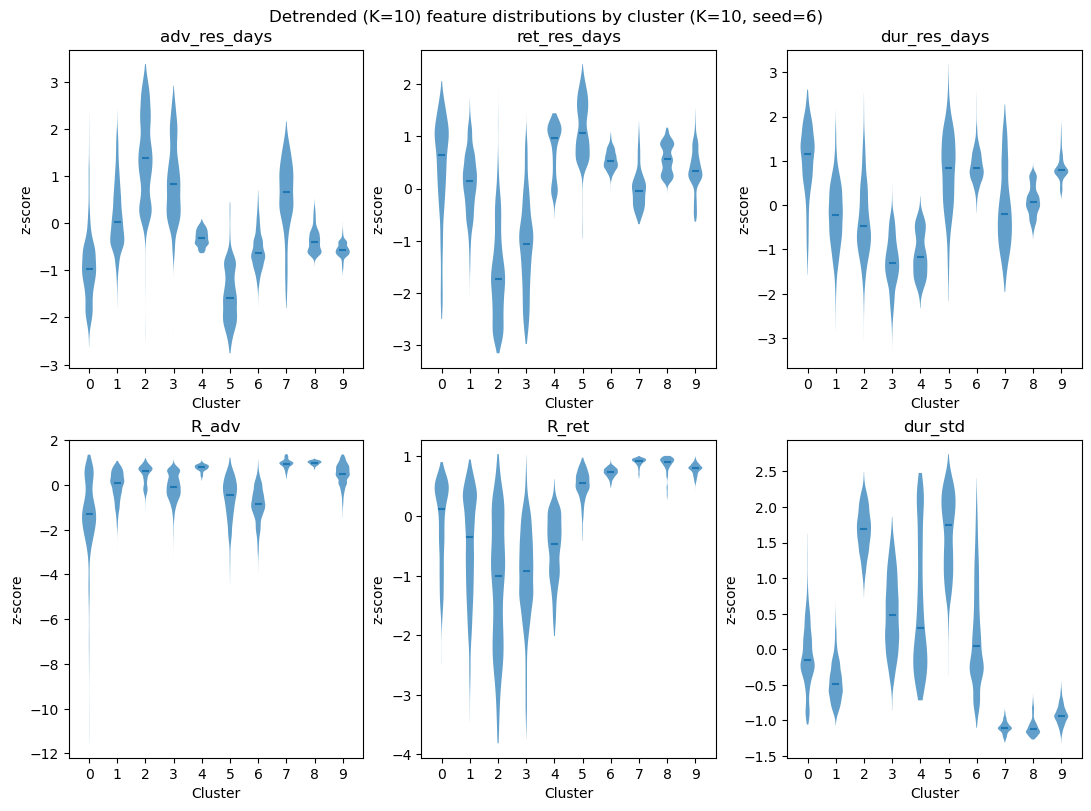

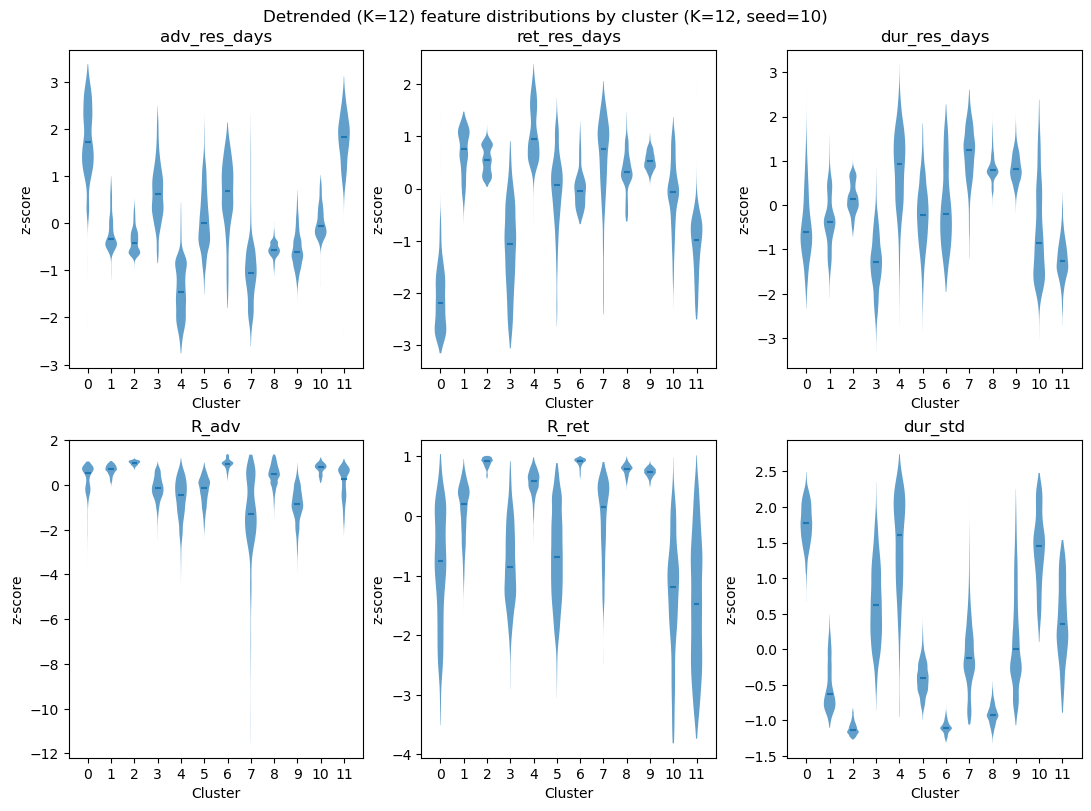

In [21]:
# K=10
plot_feature_violins(X_res_z, res10['labels_1d'], feat_names_res, K=10, seed=res10['seed'],
                     title_prefix='Detrended (K=10)')

# K=12
plot_feature_violins(X_res_z, res12['labels_1d'], feat_names_res, K=12, seed=res12['seed'],
                     title_prefix='Detrended (K=12)')
